## Загрузка и подготовка данных

In [5]:
#!pip install kagglehub

In [21]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils import data
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
from torch.utils.data import Subset
from tqdm import tqdm


from PIL import ImageFile

Разные параметры для модели и обучения

In [22]:
ImageFile.LOAD_TRUNCATED_IMAGES = True
random.seed(42)
num_classes = 10
test_data_share = 0.1
batch_size = 32
epochs = 20
lr = 0.001
gamma = 0.78
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

Поменяем переменную среды чтобы скачать датасет куда нам надо

In [23]:
import kagglehub

KAGGLEHUB_CACHE = "C:/Users/alesh/PycharmProjects/PythonProject/data"
path = kagglehub.dataset_download("maysee/mushrooms-classification-common-genuss-images")

path =path + '/Mushrooms/Mushrooms'

In [24]:
train_transforms = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transforms = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


In [25]:
full_dataset = torchvision.datasets.ImageFolder(
    root=path
)

print(f"Всего изображений в датасете: {len(full_dataset)}")

# Получаем метки для стратификации
y = [label for _, label in full_dataset.samples]

# Разделяем индексы с сохранением распределения классов
train_idx, test_idx = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train индексы: {len(train_idx)}")
print(f"Test индексы: {len(test_idx)}")

Всего изображений в датасете: 6714
Train индексы: 5371
Test индексы: 1343


In [26]:
# Класс для трансформаций
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


# Без трансформаций
train_subset = Subset(full_dataset, train_idx)
test_subset = Subset(full_dataset, test_idx)

# Применяем трансформации
train_dataset = TransformedSubset(train_subset, transform=train_transforms)
test_dataset = TransformedSubset(test_subset, transform=test_transforms)

print(f"Train: {len(train_dataset)} изображений")
print(f"Test: {len(test_dataset)} изображений")

Train: 5371 изображений
Test: 1343 изображений


In [10]:
# Классы
mushrooms_classes = ["Agaricus", "Amanita", "Boletus", "Cortinarius", "Entoloma", "Hygrocybe", "Lactarius", "Russula", "Suillus"]

# Определение устройства
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cuda


## Создание модели EfficientNet

In [27]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Замораживаем все слои кроме последних
for param in model.parameters():
    param.requires_grad = False

# Размораживаем последние 3 слоя
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Классификатор
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, 1024),
    nn.BatchNorm1d(1024),
    nn.SiLU(inplace=True),  #активация
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.SiLU(inplace=True),
    nn.Dropout(p=0.1, inplace=True),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.SiLU(inplace=True),
    nn.Linear(256, num_classes)
)

model = model.to(device)

In [12]:
train_data_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_data_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

## Функция обучения, оценки, создания графика

In [13]:
def train(model, train_data_loader, test_data_loader):
    model.train()

    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)  # AdamW лучше для EfficientNet
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        running_loss = 0.0
        total_loss = 0
        total = 0
        correct = 0

        progress_bar = tqdm(train_data_loader, desc=f'Epoch {epoch + 1}/{epochs}')

        for i, (inputs, labels) in enumerate(progress_bar):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            _, predicted = outputs.max(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # Статистика
            total_loss += loss.item()
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Обновляем прогресс-бар
            progress_bar.set_postfix({
                'Loss': f'{running_loss / (i + 1):.4f}',
                'Acc': f'{100. * correct / total:.2f}%'
            })

        epoch_loss = total_loss / len(train_data_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Оценка на тестовых данных
        test_acc = evaluate(model, test_data_loader, device)

        print(
            f'Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, Test Acc: {test_acc:.2f}%')
        print(f'Learning Rate: {scheduler.get_last_lr()[0]:.6f}')

        scheduler.step()

    return train_losses, train_accuracies

In [14]:
def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    return accuracy

In [15]:
def plot_training_history(losses, accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(accuracies)
    ax2.set_title('Training Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## Запуск модели

In [16]:
print(f"Training EfficientNet-B0 on {device}")
print(f"Input size: 380x380")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {lr}")

# Обучение
train_losses, train_accuracies = train(model, train_data_loader, test_data_loader)

Training EfficientNet-B0 on cuda
Input size: 380x380
Batch size: 32
Learning rate: 0.001


Evaluating: 100%|██████████| 42/42 [00:23<00:00,  1.80it/s]


Epoch [1/20], Loss: 0.9764, Train Acc: 67.88%, Test Acc: 82.13%
Learning Rate: 0.001000


Evaluating: 100%|██████████| 42/42 [00:12<00:00,  3.37it/s]


Epoch [2/20], Loss: 1.7380, Train Acc: 39.40%, Test Acc: 51.38%
Learning Rate: 0.000994


...

Epoch [18/20], Loss: 0.0198, Train Acc: 99.40%, Test Acc: 92.55%
Learning Rate: 0.000054


Evaluating: 100%|██████████| 42/42 [00:12<00:00,  3.27it/s]


Epoch [19/20], Loss: 0.0205, Train Acc: 99.22%, Test Acc: 92.48%
Learning Rate: 0.000024


Evaluating: 100%|██████████| 42/42 [00:12<00:00,  3.28it/s]

Epoch [20/20], Loss: 0.0136, Train Acc: 99.52%, Test Acc: 92.55%
Learning Rate: 0.000006


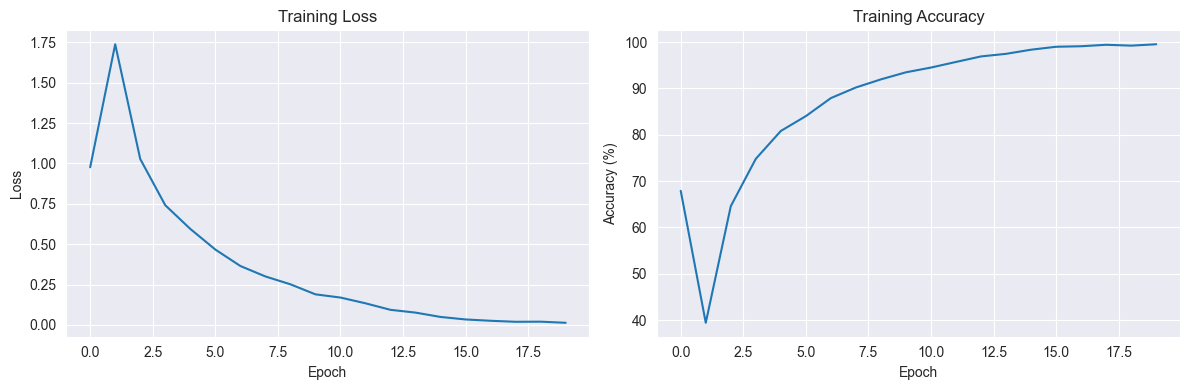

In [17]:
plot_training_history(train_losses, train_accuracies)

## Оценка

In [ ]:
test_accuracy = evaluate(model, test_data_loader, device)

In [28]:
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 92.55%
